# Pole-pair tradeoff study

How do torque, back-EMF, electrical frequency, core loss, efficiency, and
winding temperature change with pole-pair count?

In the Layer-1 model, torque at fixed air-gap field and electrical loading
is independent of pole-pair count: flux per pole falls as 1/p while the
pole count rises as p, and the two cancel in the torque expression. The
tradeoff lives elsewhere:

- Low `p` needs a thick stator yoke. Each pole's flux return scales with
  the pole pitch, so a fixed yoke saturates at low pole counts.
- High `p` raises electrical frequency linearly, which raises inverter
  switching burden and ripple, while shorter end turns reduce copper loss.

The second sweep at the end of this notebook shows where the familiar
"more poles is better" intuition actually comes from: resizing the iron
with p raises torque density several-fold while torque stays constant.

In [1]:
from pathlib import Path

from axfluxmdo import AxialFluxMotor, OperatingPoint
from axfluxmdo.sweeps import sweep_pole_pairs

OUTPUT_DIR = Path(__file__).parent / "output" if "__file__" in globals() else Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

In [2]:
motor = AxialFluxMotor(
    outer_radius=0.08,
    inner_radius=0.025,
    air_gap=0.0008,
    pole_pairs=14,
    phases=3,
    turns_per_phase=24,
    fill_factor=0.45,
    magnet_thickness=0.004,
    back_iron_thickness=0.006,
)
op = OperatingPoint(speed_rpm=500, current_rms=25, dc_bus_voltage=48)

## Sweep p = 4 … 20

In [3]:
sweep = sweep_pole_pairs(motor, op, pole_pairs=range(4, 21, 2))

data = sweep.to_arrays(
    "torque_nm", "electrical_frequency_hz", "core_loss_w", "efficiency", "winding_temp_c"
)
for p, t, f, pc in zip(
    data["pole_pairs"],
    data["torque_nm"],
    data["electrical_frequency_hz"],
    data["core_loss_w"],
    strict=True,
):
    print(f"p={p:3.0f}  torque={t:6.2f} N·m  f_e={f:6.1f} Hz  core loss={pc:5.2f} W")

p=  4  torque=  8.63 N·m  f_e=  33.3 Hz  core loss= 1.66 W
p=  6  torque=  8.63 N·m  f_e=  50.0 Hz  core loss= 1.35 W
p=  8  torque=  8.63 N·m  f_e=  66.7 Hz  core loss= 1.17 W
p= 10  torque=  8.63 N·m  f_e=  83.3 Hz  core loss= 1.06 W
p= 12  torque=  8.63 N·m  f_e= 100.0 Hz  core loss= 0.98 W
p= 14  torque=  8.63 N·m  f_e= 116.7 Hz  core loss= 0.91 W
p= 16  torque=  8.63 N·m  f_e= 133.3 Hz  core loss= 0.87 W
p= 18  torque=  8.63 N·m  f_e= 150.0 Hz  core loss= 0.83 W
p= 20  torque=  8.63 N·m  f_e= 166.7 Hz  core loss= 0.79 W


## Tradeoff plots

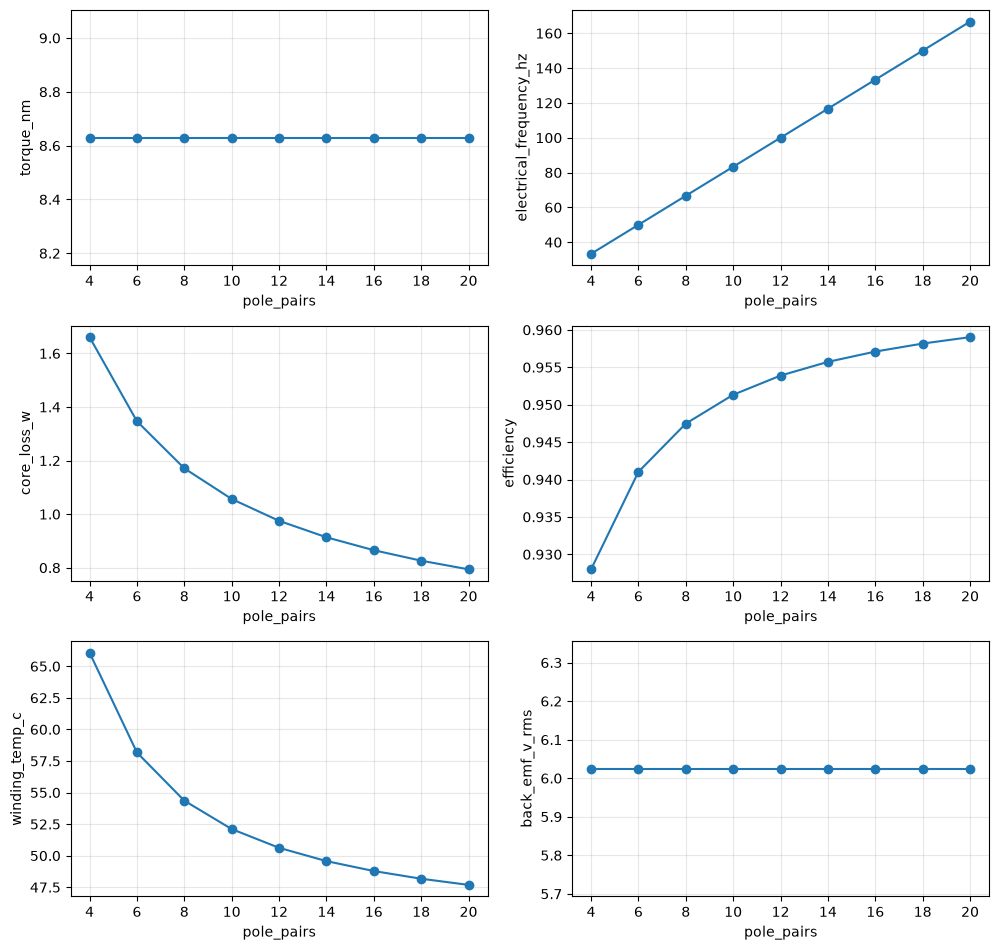

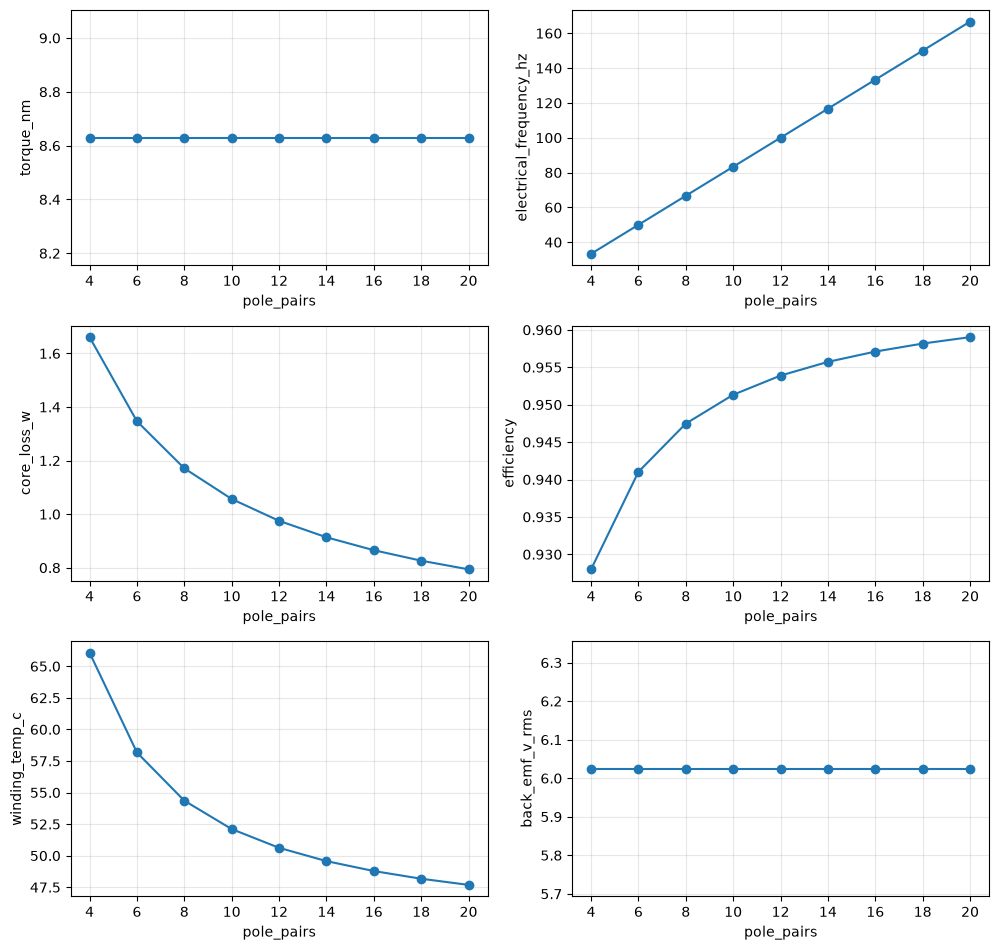

In [4]:
fig = sweep.plot(
    fields=(
        "torque_nm",
        "electrical_frequency_hz",
        "core_loss_w",
        "efficiency",
        "winding_temp_c",
        "back_emf_v_rms",
    )
)
fig.savefig(OUTPUT_DIR / "02_pole_pair_tradeoff.png", dpi=150, bbox_inches="tight")
fig

## Where do constraints bind?

At the low end, p = 4 is infeasible: with the stator core thickness held
fixed, the wide pole pitch pushes the yoke flux density past saturation. At
the high end the electrical-frequency margin shrinks linearly with `p`; at
500 rpm it never binds, but at higher shaft speeds it becomes the limiting
constraint well before thermal limits.

In [5]:
for p, r in zip(sweep.values, sweep.results, strict=True):
    by_name = {c.name: c for c in r.constraints}
    f_margin = by_name["electrical_frequency_hz"].margin
    b_yoke = by_name["core_flux_density_t"].value
    print(f"p={p:3d}  f_e margin {f_margin:+.1%}  B_yoke={b_yoke:.2f} T  feasible={r.feasible}")

p=  4  f_e margin +96.7%  B_yoke=2.34 T  feasible=False
p=  6  f_e margin +95.0%  B_yoke=1.56 T  feasible=True
p=  8  f_e margin +93.3%  B_yoke=1.17 T  feasible=True
p= 10  f_e margin +91.7%  B_yoke=0.94 T  feasible=True
p= 12  f_e margin +90.0%  B_yoke=0.78 T  feasible=True
p= 14  f_e margin +88.3%  B_yoke=0.67 T  feasible=True
p= 16  f_e margin +86.7%  B_yoke=0.59 T  feasible=True
p= 18  f_e margin +85.0%  B_yoke=0.52 T  feasible=True
p= 20  f_e margin +83.3%  B_yoke=0.47 T  feasible=True


## Where the "more poles = more torque" intuition comes from

Torque is flat above because the sweep holds the geometry fixed. The
benefit of high pole counts is torque *density*: each pole's flux return
scales with the pole pitch, so the required yoke thickness scales as 1/p.
Resizing the rotor back iron and stator core accordingly (holding yoke
flux density constant) leaves torque unchanged but removes iron mass.

In [6]:
import dataclasses

from axfluxmdo.models import AnalyticalModel

model = AnalyticalModel()
P_REF = motor.pole_pairs  # yokes sized for p=14 in the reference design

print("fixed geometry            vs   yokes resized as 1/p (constant B_yoke)")
for p in range(4, 21, 2):
    fixed = model.evaluate(dataclasses.replace(motor, pole_pairs=p), op)
    scale = P_REF / p
    scaled_motor = dataclasses.replace(
        motor,
        pole_pairs=p,
        stator_core_thickness=motor.stator_core_thickness * scale,
        back_iron_thickness=motor.back_iron_thickness * scale,
    )
    scaled = model.evaluate(scaled_motor, op)
    print(
        f"p={p:3d}  T={fixed.torque_nm:5.2f} N·m  {fixed.torque_density_nm_kg:5.2f} N·m/kg"
        f"   |   T={scaled.torque_nm:5.2f} N·m  {scaled.torque_density_nm_kg:5.2f} N·m/kg"
        f"  (mass {scaled.mass_kg:5.2f} kg)"
    )

fixed geometry            vs   yokes resized as 1/p (constant B_yoke)
p=  4  T= 8.63 N·m   2.12 N·m/kg   |   T= 8.63 N·m   0.87 N·m/kg  (mass  9.96 kg)
p=  6  T= 8.63 N·m   2.23 N·m/kg   |   T= 8.63 N·m   1.23 N·m/kg  (mass  7.02 kg)
p=  8  T= 8.63 N·m   2.29 N·m/kg   |   T= 8.63 N·m   1.56 N·m/kg  (mass  5.54 kg)
p= 10  T= 8.63 N·m   2.32 N·m/kg   |   T= 8.63 N·m   1.85 N·m/kg  (mass  4.66 kg)
p= 12  T= 8.63 N·m   2.35 N·m/kg   |   T= 8.63 N·m   2.12 N·m/kg  (mass  4.07 kg)
p= 14  T= 8.63 N·m   2.36 N·m/kg   |   T= 8.63 N·m   2.36 N·m/kg  (mass  3.65 kg)
p= 16  T= 8.63 N·m   2.38 N·m/kg   |   T= 8.63 N·m   2.59 N·m/kg  (mass  3.34 kg)
p= 18  T= 8.63 N·m   2.39 N·m/kg   |   T= 8.63 N·m   2.79 N·m/kg  (mass  3.09 kg)
p= 20  T= 8.63 N·m   2.40 N·m/kg   |   T= 8.63 N·m   2.98 N·m/kg  (mass  2.89 kg)


Torque is identical in both columns at every pole count. In the fixed
sweep, torque density rises only ~13% (shorter end turns shrink the copper
mass). In the design-scaled sweep it rises ~3.4x, because the iron shrinks
with p. Thinner yokes at constant air-gap shear, not extra torque, are why
optimized high-pole machines win in robotics joints and direct-drive
applications. The
[pole-pair explainer](https://jman4162.github.io/axfluxmdo/guide/analytical-model/#4-pole-pairs-and-torque-a-common-misconception)
in the docs works through the algebra.